In [1]:
# Установка необходимых библиотек (выполнить один раз)
!pip install pymorphy3 wordcloud

# Импорт библиотек
import numpy as np
import pandas as pd
import re
import nltk
import string
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
from datetime import datetime, timedelta
import random
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import pymorphy3

# Загрузка ресурсов NLTK
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 37.5 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [2]:
# Загружаем данные из CSV
# ВАЖНО: вам нужно загрузить файл 'reviews.csv' в Colab
# Для этого выполните:
from google.colab import files
uploaded = files.upload()

# Читаем данные
df = pd.read_csv('reviews.csv', encoding='utf-8', sep='\t')
print("Первые 5 строк датасета:")
df.head()

Saving reviews.csv to reviews (1).csv
Первые 5 строк датасета:


,review,sentiment
0,качество плохое пошив ужасный (горловина напер...,negative
1,"Товар отдали другому человеку, я не получила п...",negative
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative
3,"товар не пришел, продавец продлил защиту без м...",negative
4,"Кофточка голая синтетика, носить не возможно.",negative


In [3]:
# 3.1 Базовая очистка (нижний регистр, удаление пунктуации, чисел)
df['cleaned_reviews'] = df['review'].str.lower()
df['cleaned_reviews'] = df['cleaned_reviews'].str.replace(r'[^\w\s]', '', regex=True)
df['cleaned_reviews'] = df['cleaned_reviews'].str.replace(r'\d+', '', regex=True)

print("После базовой очистки:")
df[['review', 'cleaned_reviews']].head()

После базовой очистки:


,review,cleaned_reviews
0,качество плохое пошив ужасный (горловина напер...,качество плохое пошив ужасный горловина напере...
1,"Товар отдали другому человеку, я не получила п...",товар отдали другому человеку я не получила по...
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",ужасная синтетика тонкая ничего общего с предс...
3,"товар не пришел, продавец продлил защиту без м...",товар не пришел продавец продлил защиту без мо...
4,"Кофточка голая синтетика, носить не возможно.",кофточка голая синтетика носить не возможно


In [4]:
# 3.2 Удаление стоп-слов
STOPWORDS = set(stopwords.words('russian'))
def remove_stopwords(text):
    return " ".join([word for word in str(text).split() if word not in STOPWORDS])

df["cleaned_reviews"] = df["cleaned_reviews"].apply(remove_stopwords)

print("После удаления стоп-слов:")
df[['review', 'cleaned_reviews']].head()

После удаления стоп-слов:


,review,cleaned_reviews
0,качество плохое пошив ужасный (горловина напер...,качество плохое пошив ужасный горловина напере...
1,"Товар отдали другому человеку, я не получила п...",товар отдали другому человеку получила посылку...
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",ужасная синтетика тонкая общего представленной...
3,"товар не пришел, продавец продлил защиту без м...",товар пришел продавец продлил защиту моего сог...
4,"Кофточка голая синтетика, носить не возможно.",кофточка голая синтетика носить возможно


In [5]:
# 3.3 Удаление самых частотных слов
cnt = Counter()
for text in df["cleaned_reviews"].values:
    for word in text.split():
        cnt[word] += 1

print("Самые частотные слова:")
print(cnt.most_common(20))

# Удаляем топ-10 самых частотных слов
freq = set([w for (w, wc) in cnt.most_common(10)])
def remove_freq_words(text):
    return " ".join([word for word in str(text).split() if word not in freq])

df["cleaned_reviews"] = df["cleaned_reviews"].apply(remove_freq_words)
print("\nПосле удаления частотных слов:")
df[['review', 'cleaned_reviews']].head()

Самые частотные слова:
[('очень', 27817), ('размер', 19166), ('товар', 12799), ('качество', 12272), ('деньги', 11952), ('продавец', 11917), ('это', 8333), ('заказ', 7712), ('доставка', 7702), ('ткань', 6797), ('спор', 6451), ('вернули', 6303), ('платье', 6302), ('заказала', 6263), ('соответствует', 6064), ('спасибо', 6036), ('фото', 5772), ('рост', 5681), ('быстро', 5535), ('цвет', 5531)]

После удаления частотных слов:


,review,cleaned_reviews
0,качество плохое пошив ужасный (горловина напер...,плохое пошив ужасный горловина наперекос фото ...
1,"Товар отдали другому человеку, я не получила п...",отдали другому человеку получила посылку ладно...
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",ужасная синтетика тонкая общего представленной...
3,"товар не пришел, продавец продлил защиту без м...",пришел продлил защиту моего согласия продавца ...
4,"Кофточка голая синтетика, носить не возможно.",кофточка голая синтетика носить возможно


In [6]:
# 3.5 Удаление эмодзи
def remove_emoji(text):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

df['cleaned_reviews'] = df['cleaned_reviews'].apply(remove_emoji)
print("После удаления эмодзи:")
df[['review', 'cleaned_reviews']].head()

После удаления эмодзи:


,review,cleaned_reviews
0,качество плохое пошив ужасный (горловина напер...,плохое пошив ужасный горловина наперекос фото ...
1,"Товар отдали другому человеку, я не получила п...",отдали другому человеку получила посылку ладно...
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",ужасная синтетика тонкая общего представленной...
3,"товар не пришел, продавец продлил защиту без м...",пришел продлил защиту моего согласия продавца ...
4,"Кофточка голая синтетика, носить не возможно.",кофточка голая синтетика носить возможно


In [7]:
# 3.6 Удаление URL
def remove_urls(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)

df['cleaned_reviews'] = df['cleaned_reviews'].apply(remove_urls)
print("После удаления URL:")
df[['review', 'cleaned_reviews']].head()

После удаления URL:


,review,cleaned_reviews
0,качество плохое пошив ужасный (горловина напер...,плохое пошив ужасный горловина наперекос фото ...
1,"Товар отдали другому человеку, я не получила п...",отдали другому человеку получила посылку ладно...
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",ужасная синтетика тонкая общего представленной...
3,"товар не пришел, продавец продлил защиту без м...",пришел продлил защиту моего согласия продавца ...
4,"Кофточка голая синтетика, носить не возможно.",кофточка голая синтетика носить возможно


In [8]:
# 4.1 Токенизация
def tokenize_text(text):
    return word_tokenize(text)

df['tokenized_text'] = df['cleaned_reviews'].apply(tokenize_text)

print("После токенизации:")
df[['review', 'tokenized_text']].head()

После токенизации:


,review,tokenized_text
0,качество плохое пошив ужасный (горловина напер...,"[плохое, пошив, ужасный, горловина, наперекос,..."
1,"Товар отдали другому человеку, я не получила п...","[отдали, другому, человеку, получила, посылку,..."
2,"Ужасная синтетика! Тонкая, ничего общего с пре...","[ужасная, синтетика, тонкая, общего, представл..."
3,"товар не пришел, продавец продлил защиту без м...","[пришел, продлил, защиту, моего, согласия, про..."
4,"Кофточка голая синтетика, носить не возможно.","[кофточка, голая, синтетика, носить, возможно]"


In [9]:
# 4.2 Лемматизация
morph = pymorphy3.MorphAnalyzer()

def lemmatize_tokens(tokens):
    if not isinstance(tokens, list):
        return tokens
    return [morph.parse(word)[0].normal_form for word in tokens]

df['lemmatized_text'] = df['tokenized_text'].apply(lemmatize_tokens)

print("После лемматизации:")
df[['review', 'lemmatized_text']].head()

После лемматизации:


,review,lemmatized_text
0,качество плохое пошив ужасный (горловина напер...,"[плохой, пошив, ужасный, горловина, наперекос,..."
1,"Товар отдали другому человеку, я не получила п...","[отдать, другой, человек, получить, посылка, л..."
2,"Ужасная синтетика! Тонкая, ничего общего с пре...","[ужасный, синтетик, тонкий, общий, представить..."
3,"товар не пришел, продавец продлил защиту без м...","[прийти, продлить, защита, мой, согласие, прод..."
4,"Кофточка голая синтетика, носить не возможно.","[кофточка, голый, синтетик, носить, возможно]"


sentiment
negative    30000
neautral    30000
positive    30000
Name: count, dtype: int64


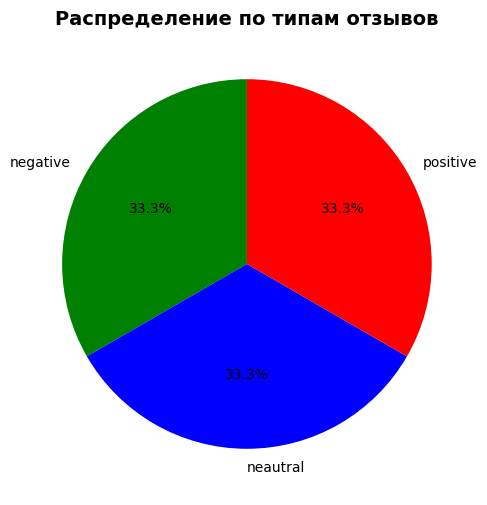

In [10]:
# 5.1 Распределение по типам отзывов
sentiment_counts = df['sentiment'].value_counts()
print(sentiment_counts)

plt.figure(figsize=(8, 6))
colors = ['green', 'blue', 'red']
plt.pie(sentiment_counts,
        labels=sentiment_counts.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90)
plt.title('Распределение по типам отзывов', fontsize=14, fontweight='bold')
plt.show()

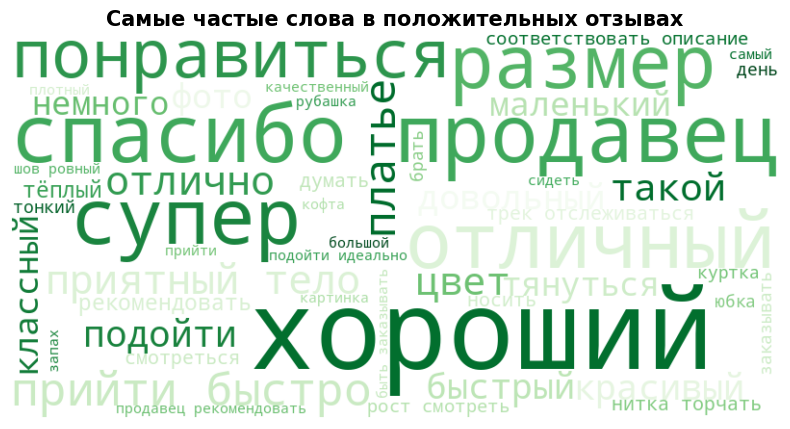

In [11]:
# 6.1 Облако слов для положительных отзывов
positive_words = df[df['sentiment'] == 'positive']['lemmatized_text'].astype(str)
pos_text = " ".join(review for review in positive_words)
pos_text = pos_text.replace("'", "").replace(",", "")

wordcloud_pos = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Greens',
    max_words=50
).generate(pos_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis("off")
plt.title('Самые частые слова в положительных отзывах',
          fontsize=15, fontweight='bold')
plt.show()

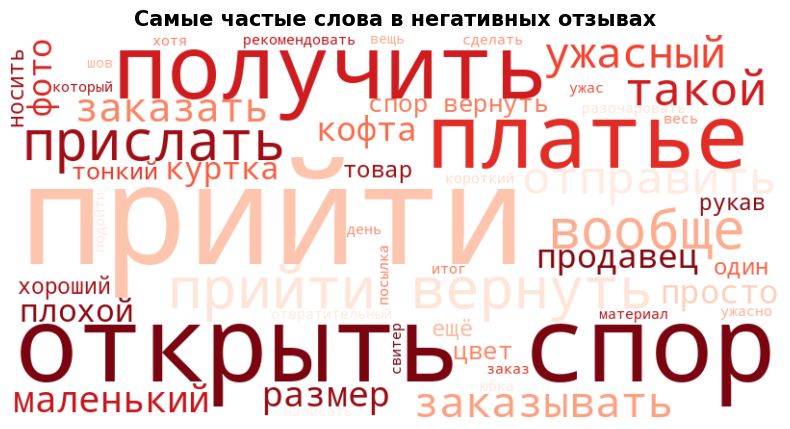

In [12]:
# 6.2 Облако слов для негативных отзывов
negative_words = df[df['sentiment'] == 'negative']['lemmatized_text']
neg_text = " ".join(" ".join(review) for review in negative_words)
neg_text = neg_text.replace("'", "").replace(",", "")

wordcloud_neg = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Reds',
    max_words=50
).generate(neg_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis("off")
plt.title('Самые частые слова в негативных отзывах',
          fontsize=15, fontweight='bold')
plt.show()

In [14]:
# 7.1 Функции для генерации случайных дат и времени
def generate_random_datetime():
    start_date = datetime(2024, 1, 1)
    end_date = datetime(2025, 1, 1)
    days_in_range = (end_date - start_date).days
    random_days = random.randint(0, days_in_range)
    random_date = start_date + timedelta(days=random_days)

    random_hour = random.randint(0, 23)
    random_minute = random.randint(0, 59)
    random_second = random.randint(0, 59)

    return random_date.replace(hour=random_hour, minute=random_minute, second=random_second)

def generate_rating(sentiment):
    if sentiment == 'positive':
        return random.randint(4, 5)
    elif sentiment == 'negative':
        return random.randint(1, 2)
    else:  # neutral
        return random.randint(3, 4)

In [15]:
# 7.2 Добавление данных в датафрейм
df['data'] = [generate_random_datetime() for _ in range(len(df))]
df['rating'] = [generate_rating(s) for s in df['sentiment']]

# Извлечение компонентов времени
df['date'] = df['data'].dt.date
df['month'] = df['data'].dt.month
df['day_of_week'] = df['data'].dt.day_name()
df['hour'] = df['data'].dt.hour
df['day_of_week_num'] = df['data'].dt.dayofweek

print("Датафрейм с временными данными:")
df.head()

Датафрейм с временными данными:


,review,sentiment,cleaned_reviews,tokenized_text,lemmatized_text,data,rating,date,month,day_of_week,hour,day_of_week_num
0,качество плохое пошив ужасный (горловина напер...,negative,плохое пошив ужасный горловина наперекос фото ...,"[плохое, пошив, ужасный, горловина, наперекос,...","[плохой, пошив, ужасный, горловина, наперекос,...",2024-01-17 10:55:48,2,2024-01-17,1,Wednesday,10,2
1,"Товар отдали другому человеку, я не получила п...",negative,отдали другому человеку получила посылку ладно...,"[отдали, другому, человеку, получила, посылку,...","[отдать, другой, человек, получить, посылка, л...",2024-03-26 14:23:09,2,2024-03-26,3,Tuesday,14,1
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative,ужасная синтетика тонкая общего представленной...,"[ужасная, синтетика, тонкая, общего, представл...","[ужасный, синтетик, тонкий, общий, представить...",2024-06-03 17:57:50,1,2024-06-03,6,Monday,17,0
3,"товар не пришел, продавец продлил защиту без м...",negative,пришел продлил защиту моего согласия продавца ...,"[пришел, продлил, защиту, моего, согласия, про...","[прийти, продлить, защита, мой, согласие, прод...",2024-10-28 18:23:52,1,2024-10-28,10,Monday,18,0
4,"Кофточка голая синтетика, носить не возможно.",negative,кофточка голая синтетика носить возможно,"[кофточка, голая, синтетика, носить, возможно]","[кофточка, голый, синтетик, носить, возможно]",2024-12-05 05:10:23,1,2024-12-05,12,Thursday,5,3


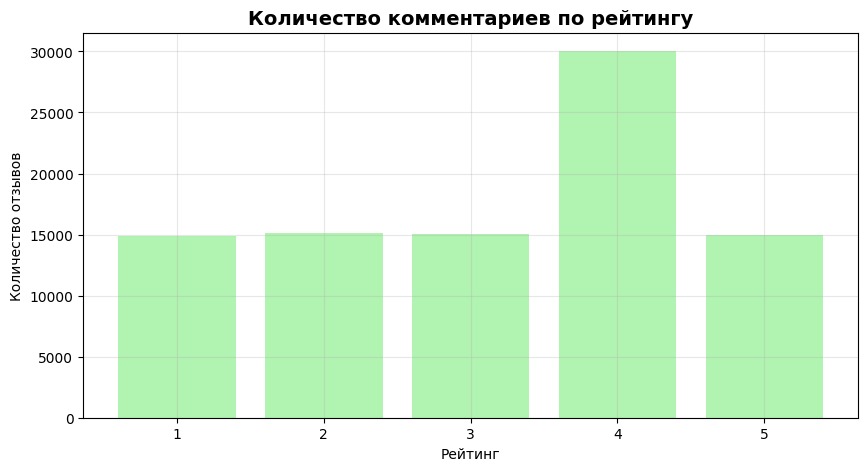

In [16]:
# 8.1 Распределение по рейтингу
plt.figure(figsize=(10, 5))
rating_counts = df['rating'].value_counts().sort_index()
plt.bar(rating_counts.index, rating_counts.values, color='lightgreen', alpha=0.7)
plt.title('Количество комментариев по рейтингу', fontsize=14, fontweight='bold')
plt.xlabel('Рейтинг')
plt.ylabel('Количество отзывов')
plt.xticks(range(1, 6))
plt.grid(True, alpha=0.3)
plt.show()

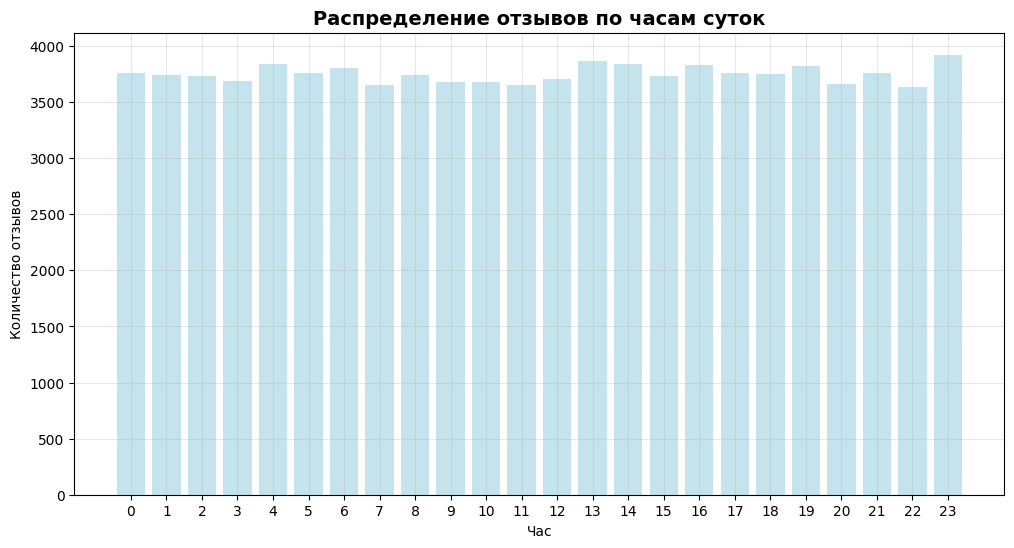

In [17]:
# 8.2 Распределение по часам
plt.figure(figsize=(12, 6))
hour_counts = df['hour'].value_counts().sort_index()
plt.bar(hour_counts.index, hour_counts.values, color='lightblue', alpha=0.7)
plt.title('Распределение отзывов по часам суток', fontsize=14, fontweight='bold')
plt.xlabel('Час')
plt.ylabel('Количество отзывов')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

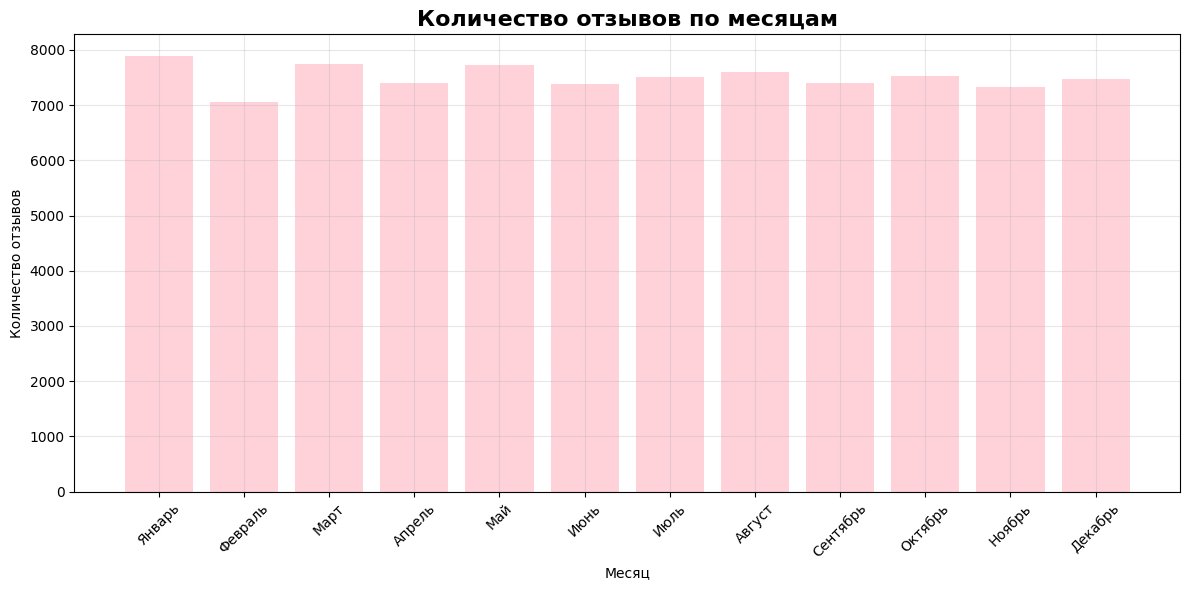

In [18]:
# 8.3 Распределение по месяцам
plt.figure(figsize=(12, 6))
month_counts = df['month'].value_counts().sort_index()
month_names = ['Январь', 'Февраль', 'Март', 'Апрель', 'Май', 'Июнь',
               'Июль', 'Август', 'Сентябрь', 'Октябрь', 'Ноябрь', 'Декабрь']

plt.bar(month_counts.index, month_counts.values, color='pink', alpha=0.7)
plt.title('Количество отзывов по месяцам', fontsize=16, fontweight='bold')
plt.xlabel('Месяц')
plt.ylabel('Количество отзывов')
plt.xticks(range(1, 13), month_names, rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()